In [2]:
import pandas as pd 
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [3]:
df = pd.read_csv("train.csv",usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
 df['Age'].fillna(df['Age'].mean(), inplace =True)

C:\Users\Sunny Kapoor\AppData\Local\Temp\ipykernel_8928\651486530.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace =True)


In [7]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [8]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
x = df.iloc[:,1:3]
y = df.iloc[: ,0]

In [10]:
# we have done train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

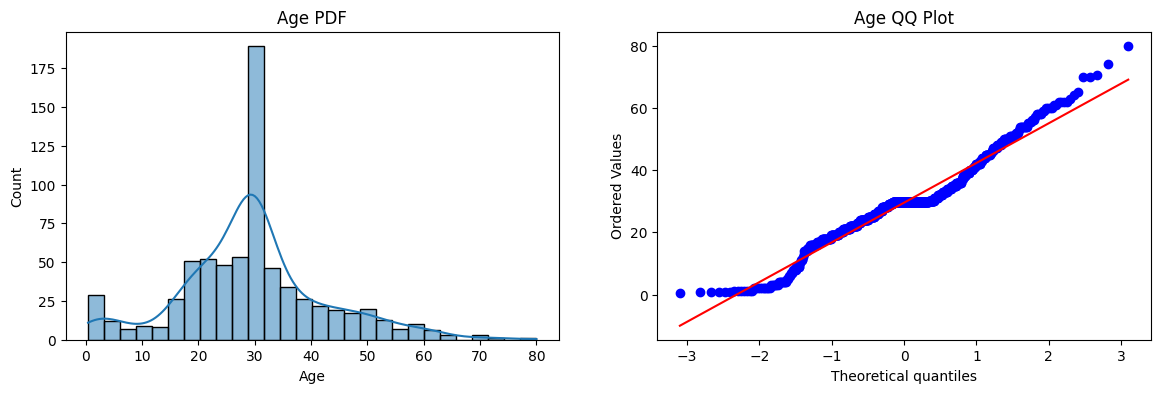

In [11]:
plt.figure(figsize=(14,4))

# Plot 1: Distribution
plt.subplot(1,2,1)
sns.histplot(x_train['Age'], kde=True)
plt.title("Age PDF")

# Plot 2: QQ Plot
plt.subplot(1,2,2)
stats.probplot(x_train["Age"], dist="norm", plot=plt)
plt.title("Age QQ Plot")

plt.show()

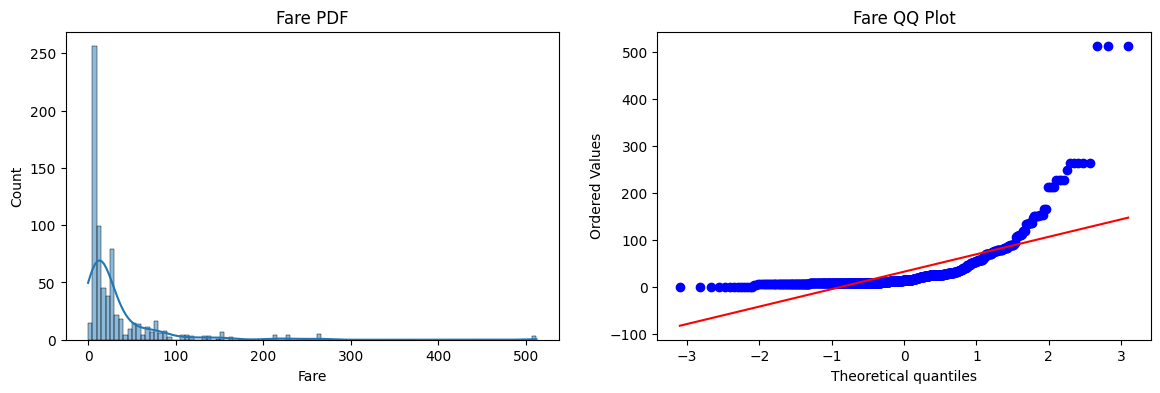

In [12]:
plt.figure(figsize=(14,4))

# Plot 1: Distribution
plt.subplot(1,2,1)
sns.histplot(x_train['Fare'], kde=True)
plt.title("Fare PDF")

# Plot 2: QQ Plot
plt.subplot(1,2,2)
stats.probplot(x_train["Fare"], dist="norm", plot=plt)
plt.title("Fare QQ Plot")

plt.show()

In [13]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [14]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred = clf.predict(x_test)
y_pred2 = clf2.predict(x_test)

print("Accuracy LR" , accuracy_score(y_test,y_pred))
print("Accuracy DC" , accuracy_score(y_test,y_pred2))

Accuracy LR 0.6480446927374302
Accuracy DC 0.664804469273743


<h2>Now what will happen when we apply Log Transformation<br> on both the column</h2> 

In [16]:
# log transform 
trf = FunctionTransformer(func=np.log1p)


In [17]:
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.fit_transform(x_test)

In [36]:
clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred = clf.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print("Accuracy LR" , accuracy_score(y_test,y_pred))
print("Accuracy DC" , accuracy_score(y_test,y_pred2))

Accuracy LR 0.6815642458100558
Accuracy DC 0.6759776536312849


<h2>Cross Validation</h2>

In [39]:
x_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf,x_transformed,y,
                                    scoring='accuracy',cv=10)))
print("DT", np.mean(cross_val_score(clf2,x_transformed,y,
                                    scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6667041198501873


<h2>Let's see , really improvement happen or not</h2>

In [43]:
# plotting qq plot for before and after transformation

Text(0.5, 1.0, 'Fare after log transformatio')

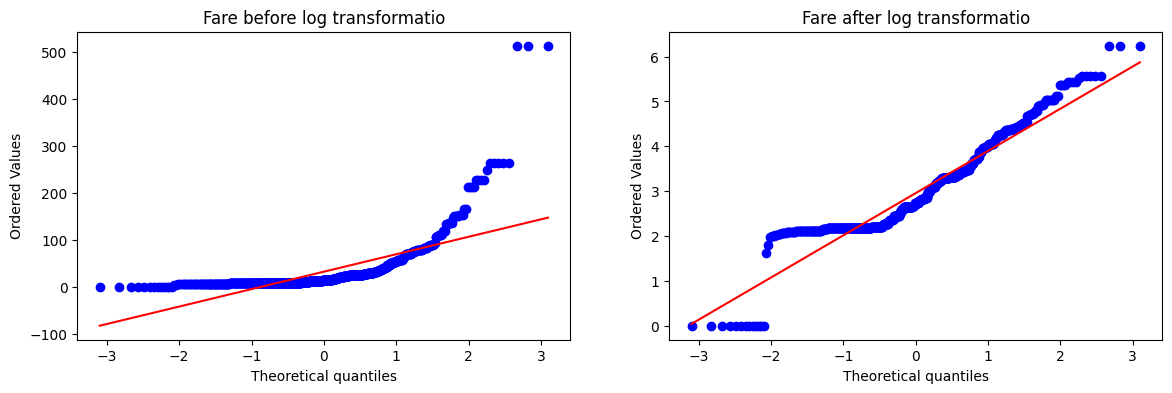

In [47]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(x_train['Fare'],dist ="norm",plot =plt)
plt.title("Fare before log transformatio")

plt.subplot(1,2,2)
stats.probplot(x_train_transformed['Fare'],dist ="norm",plot =plt)
plt.title("Fare after log transformatio")

Text(0.5, 1.0, 'Age after log transformatio')

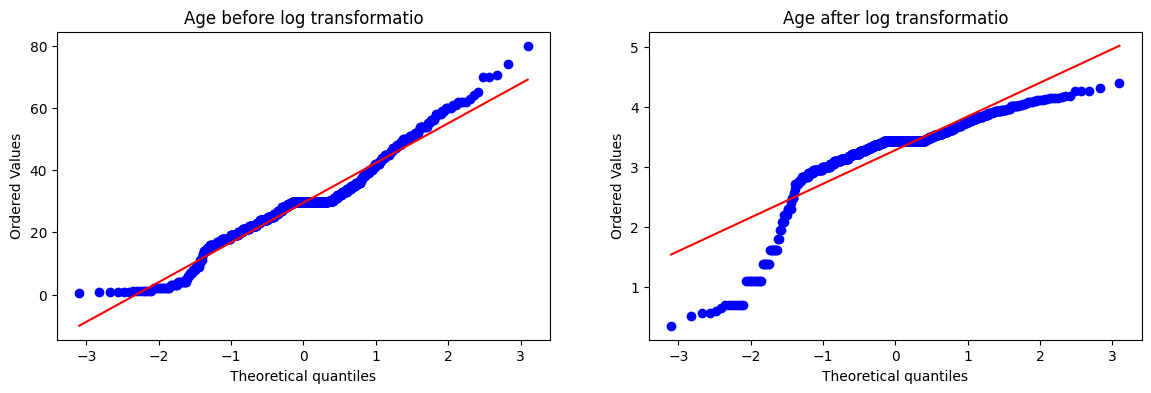

In [49]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(x_train['Age'],dist ="norm",plot =plt)
plt.title("Age before log transformatio")

plt.subplot(1,2,2)
stats.probplot(x_train_transformed['Age'],dist ="norm",plot =plt)
plt.title("Age after log transformatio")

<h3>Now applyinglog transform on the Fare column only</h3>

In [55]:
trf2 = ColumnTransformer([('log' ,FunctionTransformer(np.log1p),['Fare'])],
                         remainder='passthrough')

x_train_transformed2 = trf2.fit_transform(x_train)
x_test_transformed2 = trf2.fit_transform(x_test)

In [59]:
clf = LogisticRegression()
clf = DecisionTreeClassifier()

clf.fit(x_train_transformed2,y_train)
clf2.fit(x_train_transformed2,y_train)

y_pred = clf.predict(x_test_transformed2)
y_pred2 = clf2.predict(x_test_transformed2)

print("Accuracy LR" , accuracy_score(y_test,y_pred))
print("Accuracy DC" , accuracy_score(y_test,y_pred2))

Accuracy LR 0.6815642458100558
Accuracy DC 0.6703910614525139


In [61]:
x_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf,x_transformed2,y,
                                    scoring='accuracy',cv=10)))
print("DT", np.mean(cross_val_score(clf2,x_transformed2,y,
                                    scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6644569288389512


In [68]:
def apply_transform(transform):
    x = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    x_trans = trf.fit_transform(x)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,x_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(1,2,1)
    stats.probplot(x['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(x_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6589013732833957


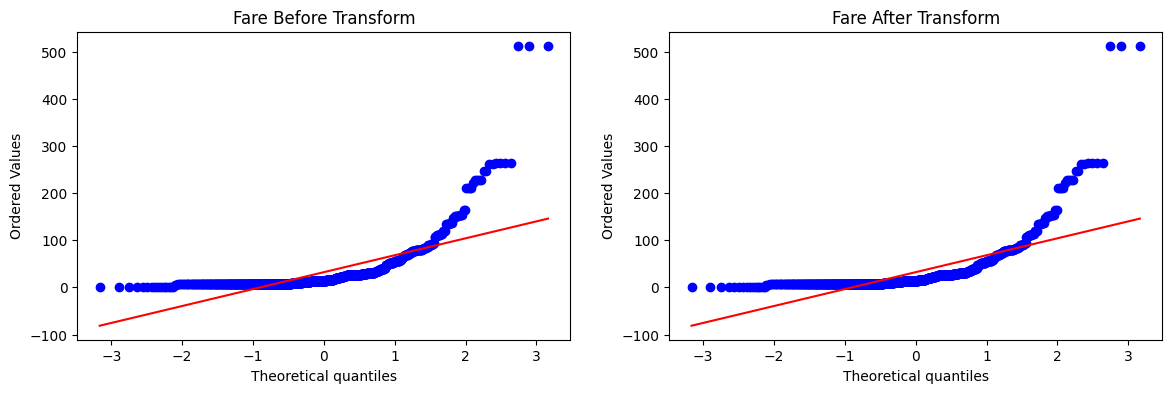

In [70]:
apply_transform(lambda x:x)

Accuracy 0.6431335830212235


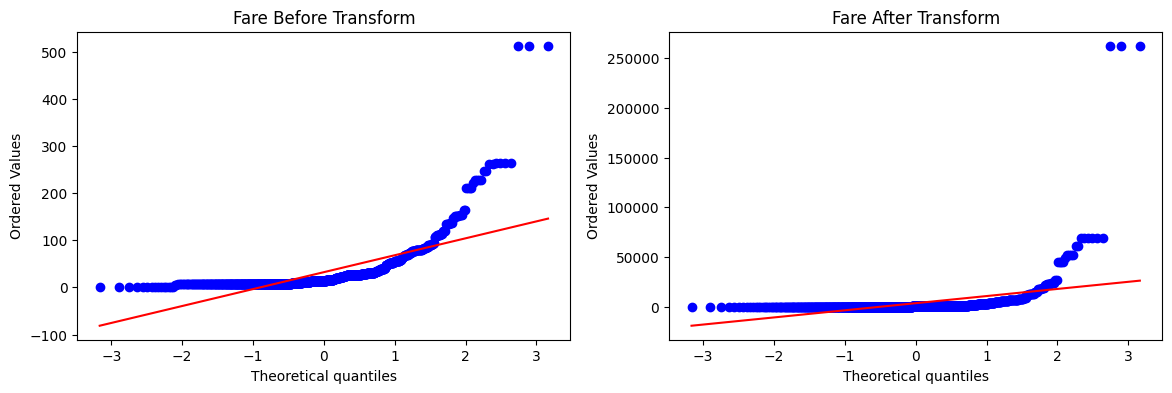

In [74]:
apply_transform(lambda x:x**2) # applying square transformation

Accuracy 0.6262796504369538


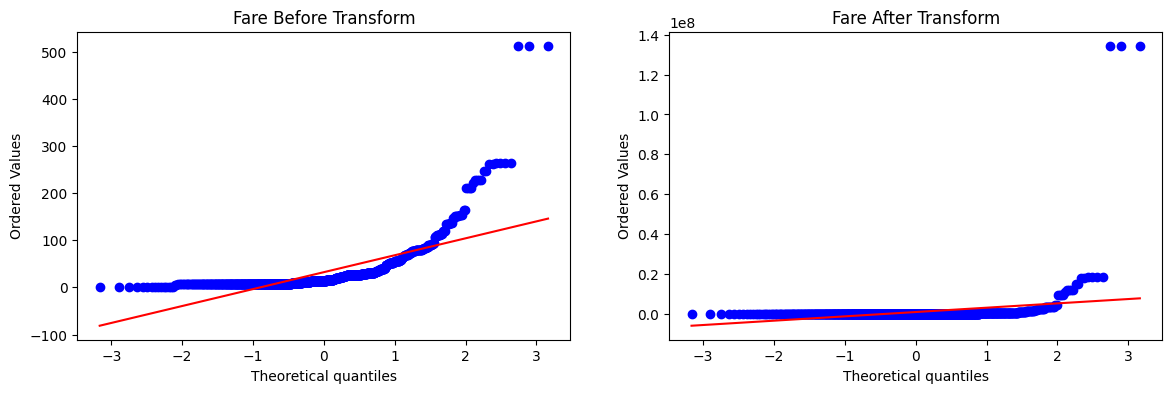

In [76]:
apply_transform(lambda x:x**3) # applying cube transformation

Accuracy 0.6589013732833957


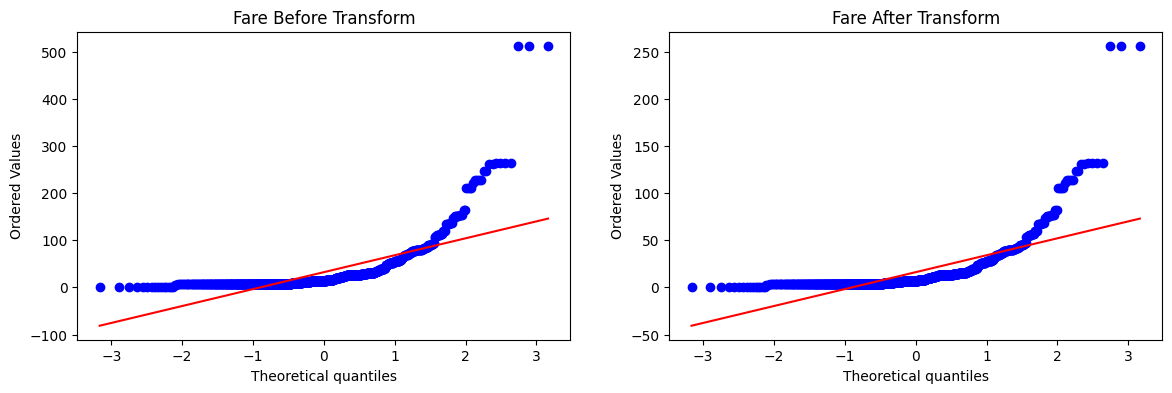

In [82]:
apply_transform(lambda x:x**1/2) # applying squareRoot transformation

Accuracy 0.61729088639201


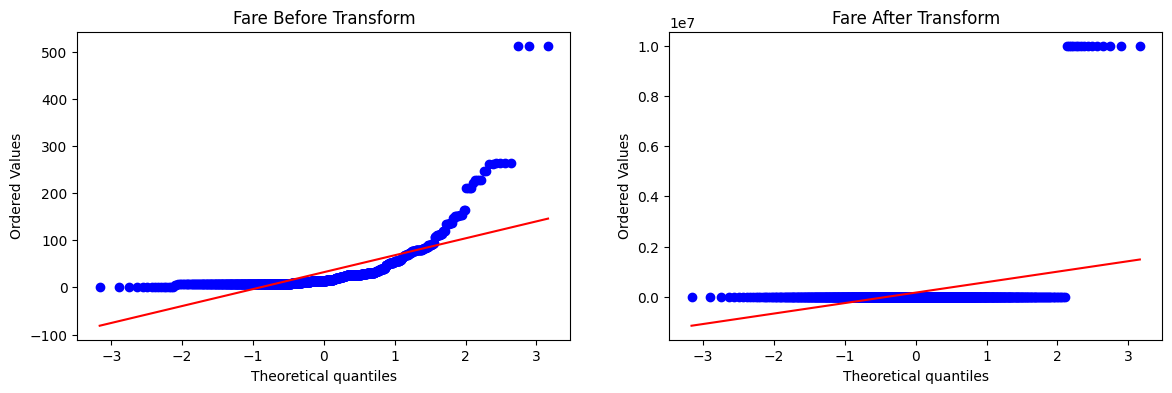

In [94]:
apply_transform(lambda x:1/(x+0.0000001))

Accuracy 0.6195131086142323


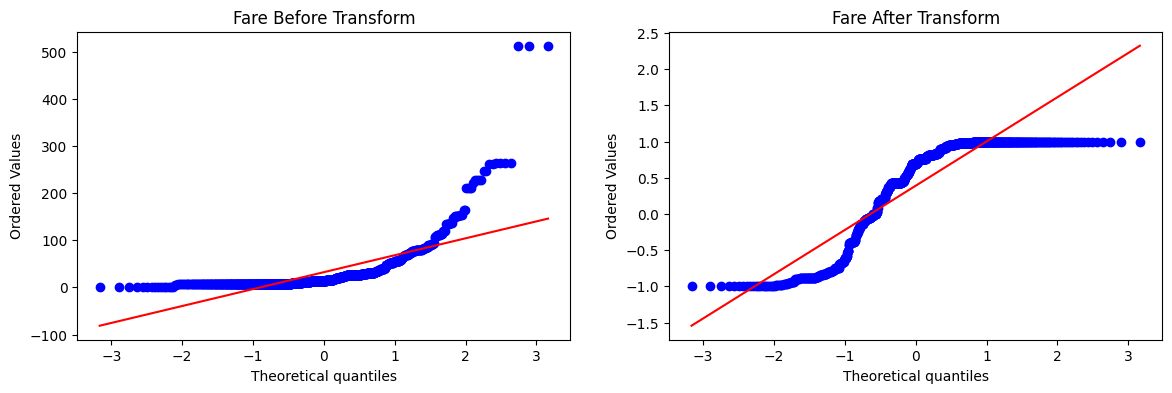

In [96]:
apply_transform(np.sin) 